# MC 07 — Candidate Selection

Create transparent selection matrices using primary metrics and explicit guardrails.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "model_comparison.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/model_comparison.yaml')

e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\model_comparison\plotting.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_pe

MODEL COMPARISON & SELECTION COMPLETED
2025 final holdout evaluated: NO
Forecasting primary candidate: Random Forest Regressor
Peak-Risk primary candidate: Logistic Regression
IMPORTANT: Review guardrails and stress tests before approving the final candidate decision.


,model_key,model,family,mae,rmse,mape,wape,bias,abs_bias,n_observations,...,short_horizon_mae_h01_h06,long_horizon_mae_h19_h24,m9w_2023_mae,m9w_2023_mape,m9w_2023_bias,runtime_seconds_evidence,runtime_minutes_evidence,runtime_source,primary_rank_mae,mae_improvement_vs_baseline_pct
0,random_forest,Random Forest Regressor,Bagging,542.255101,926.184858,5.552180,5.959380,-125.312178,125.312178,2519424,...,465.275552,586.564749,1188.718257,7.530991,-973.423632,NaN,NaN,unavailable,1.0,11.403262
1,lightgbm,LightGBM Regressor,Gradient Boosting,580.835973,1044.368141,5.735130,6.383384,-213.040484,213.040484,2519424,...,457.528000,650.361523,1922.876179,12.776347,NaN,NaN,NaN,unavailable,2.0,5.099699
2,sarimax,SARIMAX Rolling,Statistical Time Series,583.635455,929.486636,6.089956,6.414150,-164.621729,164.621729,2519424,...,353.600297,714.787501,1223.320380,8.124587,NaN,2223.858716,37.064312,runtime_diagnostics:sum(task_seconds),3.0,4.642303
3,xgboost,XGBoost Regressor,Gradient Boosting,606.265878,1106.771204,5.929867,6.662859,-251.046293,251.046293,2519424,...,471.395129,676.298633,2158.561949,14.294676,NaN,NaN,NaN,unavailable,4.0,0.944816
4,seasonal_naive,Seasonal Naive,Baseline,612.048608,994.292504,6.589649,6.726411,-0.837658,0.837658,2519424,...,612.176988,611.935396,841.600423,5.668017,-6.180456,NaN,NaN,unavailable,5.0,0.000000


,model_key,model,family,precision,recall,f1,pr_auc,roc_auc,balanced_accuracy,brier_score,...,m9w_2023_precision,m9w_2023_recall,m9w_2023_f1,m9w_2023_pr_auc,m9w_2023_roc_auc,m9w_2023_brier_score,runtime_seconds_evidence,runtime_minutes_evidence,runtime_source,primary_rank_pr_auc
0,logistic_regression,Logistic Regression,Baseline,0.843267,0.306492,0.449581,0.675276,0.943635,0.650943,NaN,...,0.915628,0.370853,0.527894,0.884445,0.912276,NaN,NaN,NaN,unavailable,1.0
1,hist_gradient_boosting,HistGradientBoosting,Gradient Boosting,0.822794,0.207605,0.331553,0.579909,0.908734,0.601994,NaN,...,0.990789,0.113782,0.204123,0.896261,0.893199,NaN,NaN,NaN,unavailable,2.0
2,random_forest,Random Forest Classifier,Bagging,0.669067,0.355315,0.464143,0.579137,0.941053,0.670551,0.044640,...,0.987990,0.172506,0.293726,0.927679,0.925991,0.302187,1354.923875,22.582065,tuning_details:sum(task_seconds),3.0
3,xgboost,XGBoost Classifier,Gradient Boosting,0.596330,0.459057,0.518766,0.556495,0.917580,0.716962,0.050577,...,0.983272,0.268872,0.422275,0.914292,0.910618,0.324131,113.649108,1.894152,tuning_details:sum(task_seconds),4.0
4,lightgbm,LightGBM Classifier,Gradient Boosting,0.555288,0.470382,0.509321,0.532379,0.909176,0.719957,0.053348,...,0.978930,0.271155,0.424678,0.907905,0.906145,0.325402,88.689420,1.478157,tuning_details:sum(task_seconds),5.0


{'forecasting_primary_candidate': 'Random Forest Regressor',
 'peak_risk_primary_candidate': 'Logistic Regression',
 'notes': ['Primary candidates are selected by the pre-declared primary metric (Forecasting: MAE; Peak-Risk: PR-AUC).',
  'Guardrails must be reviewed before the selection is considered final.',
  'The 2025 holdout remains untouched during this phase.']}

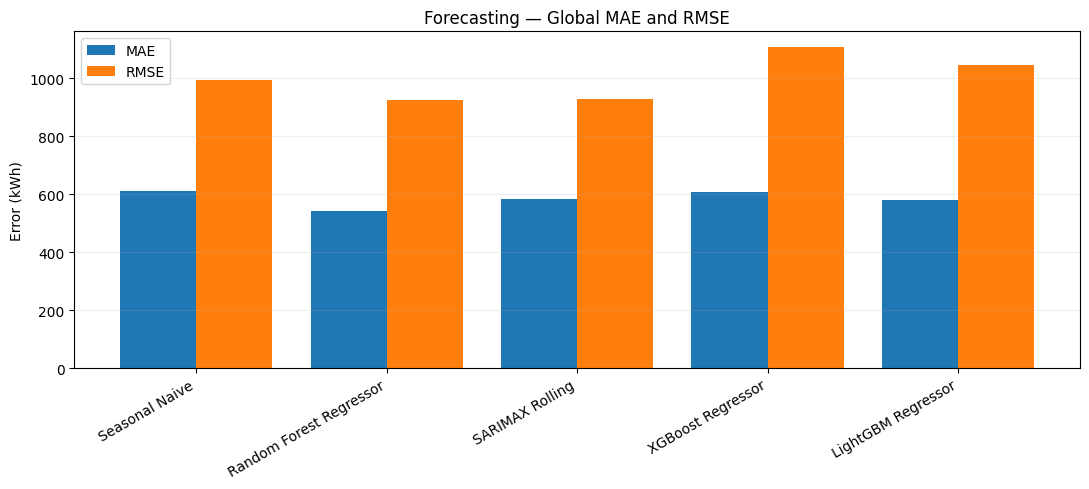

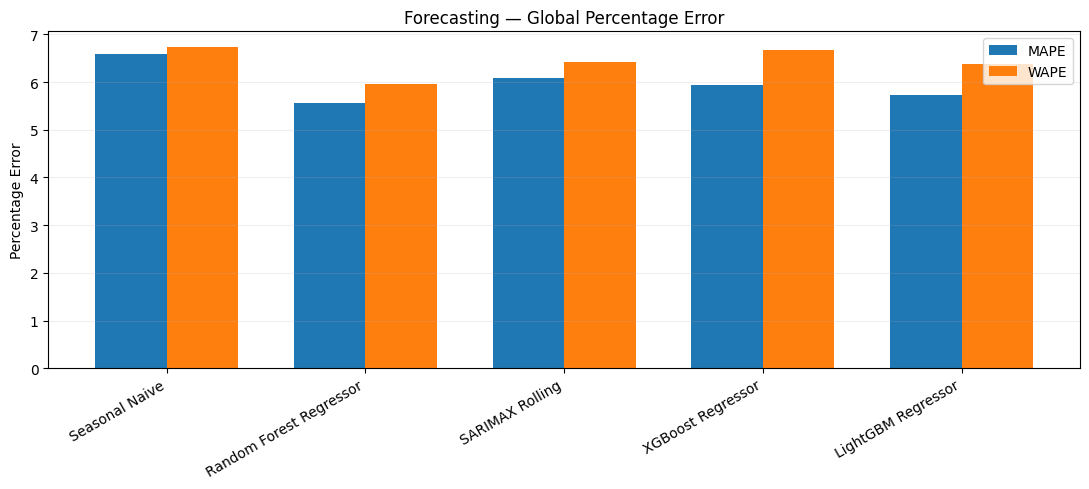

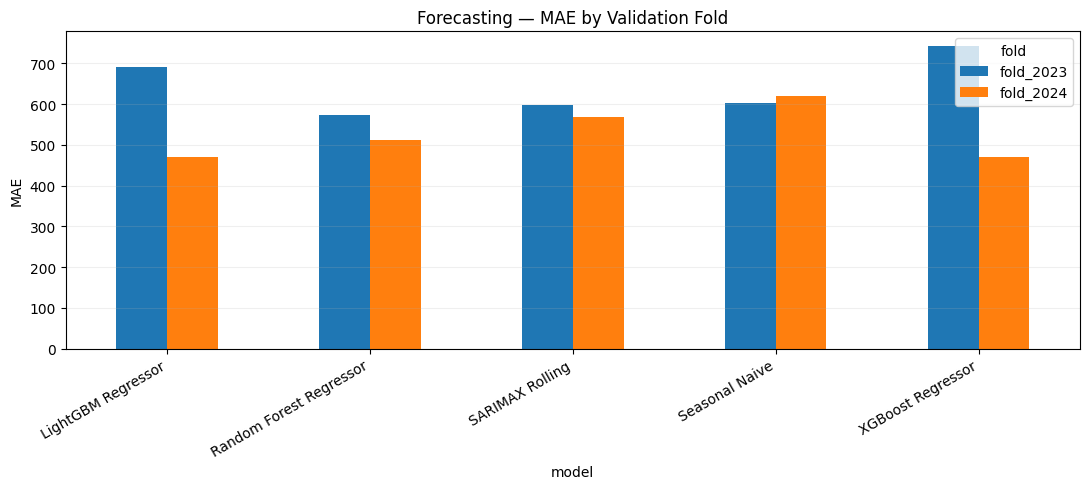

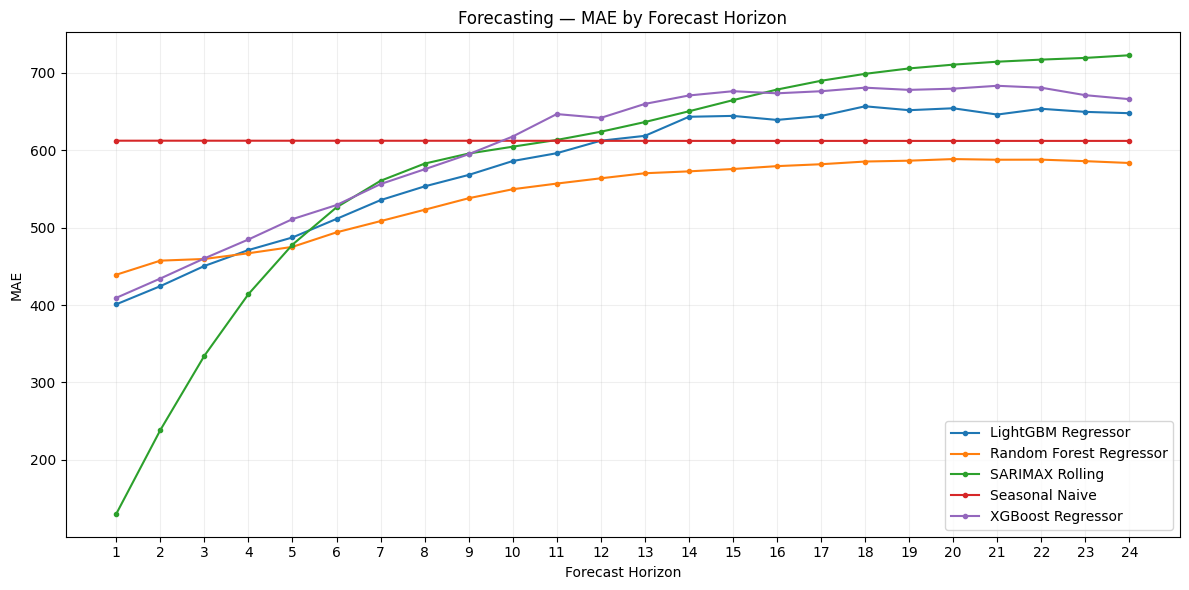

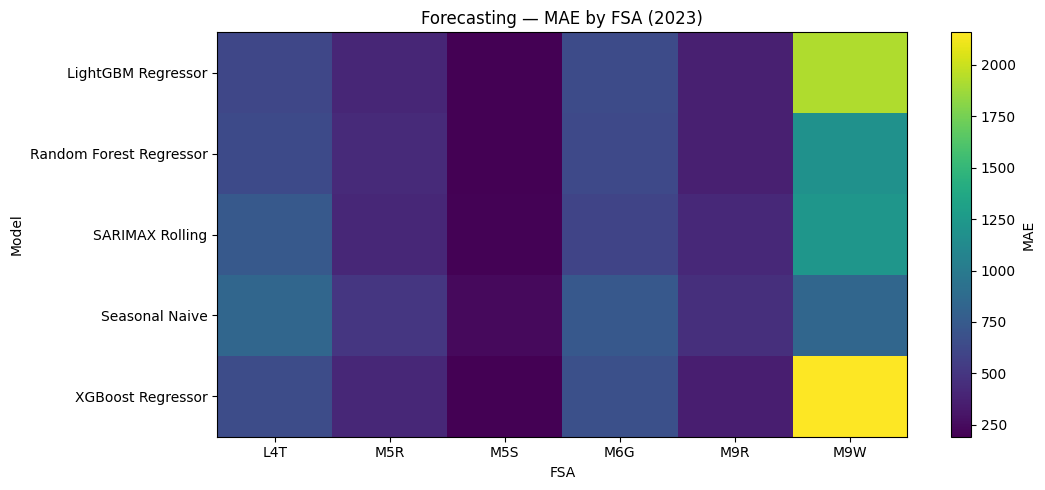

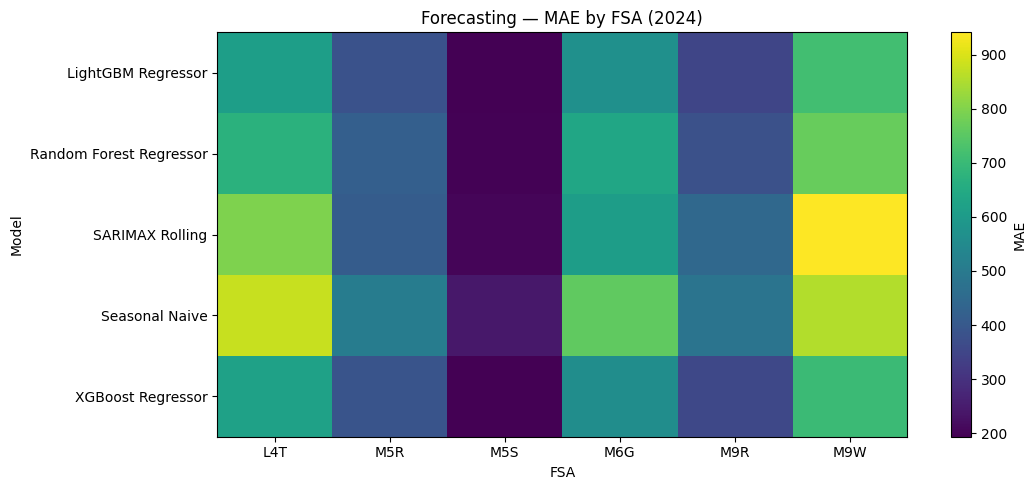

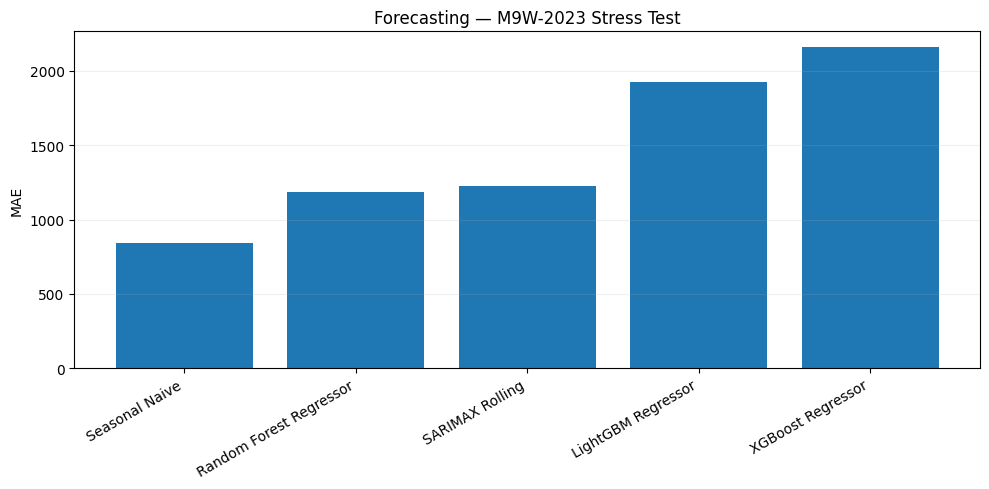

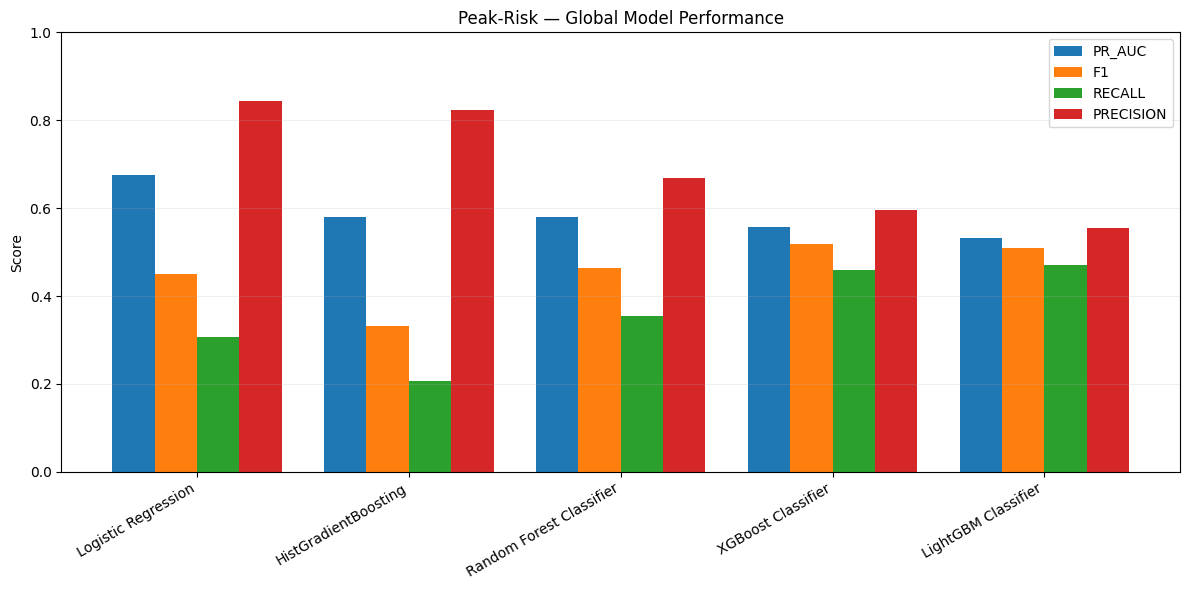

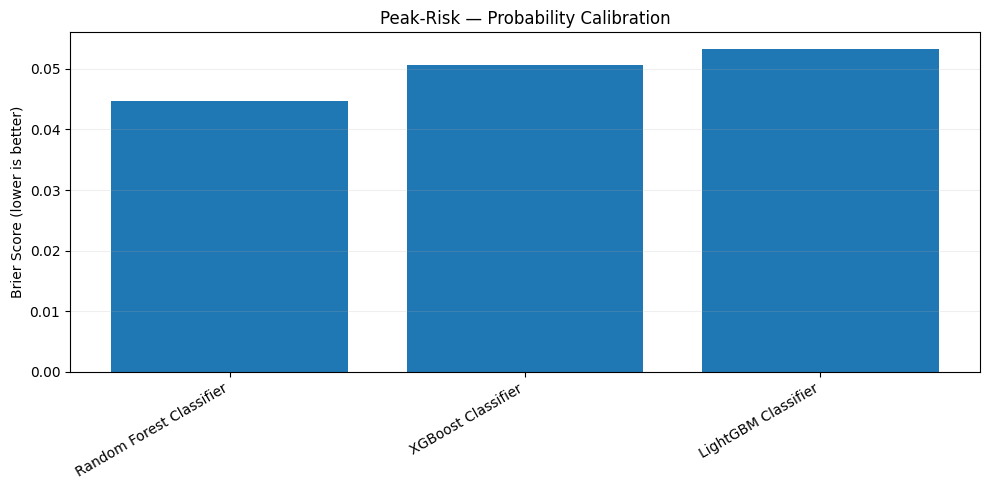

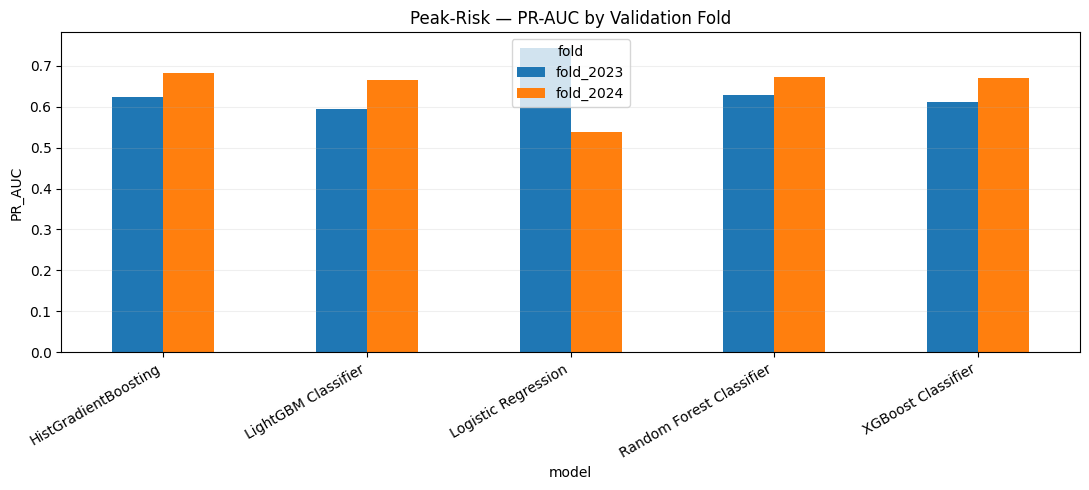

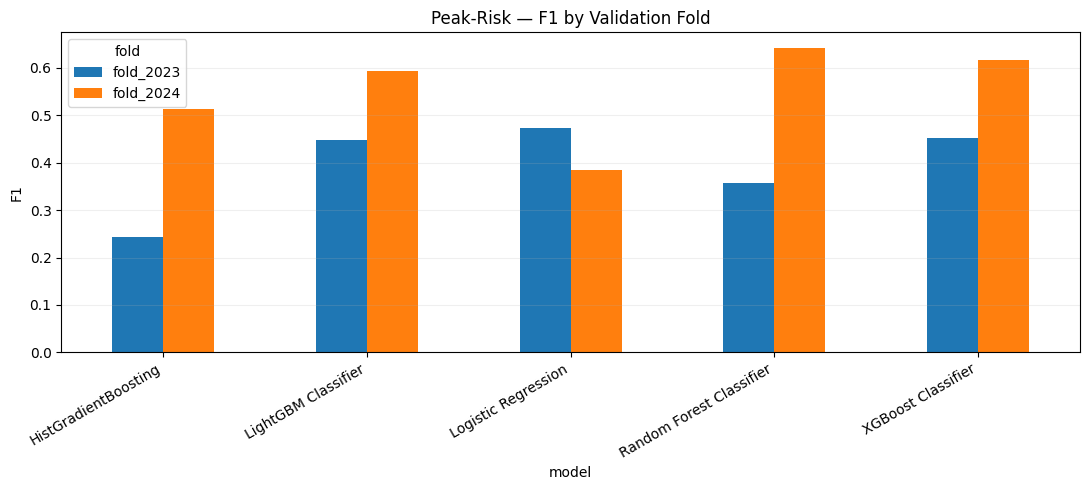

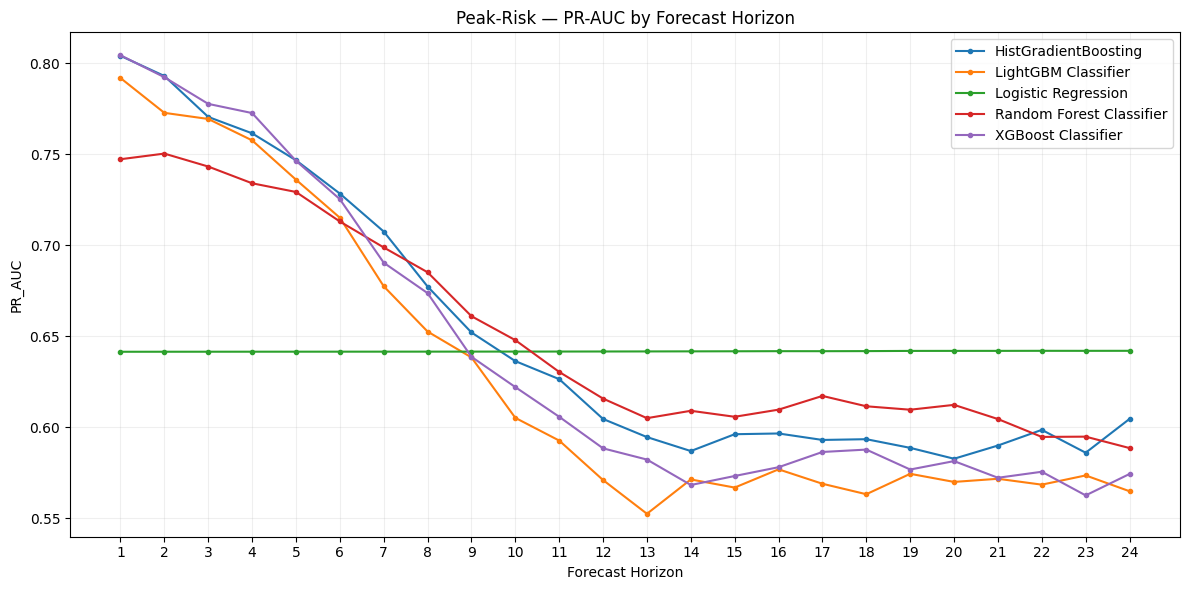

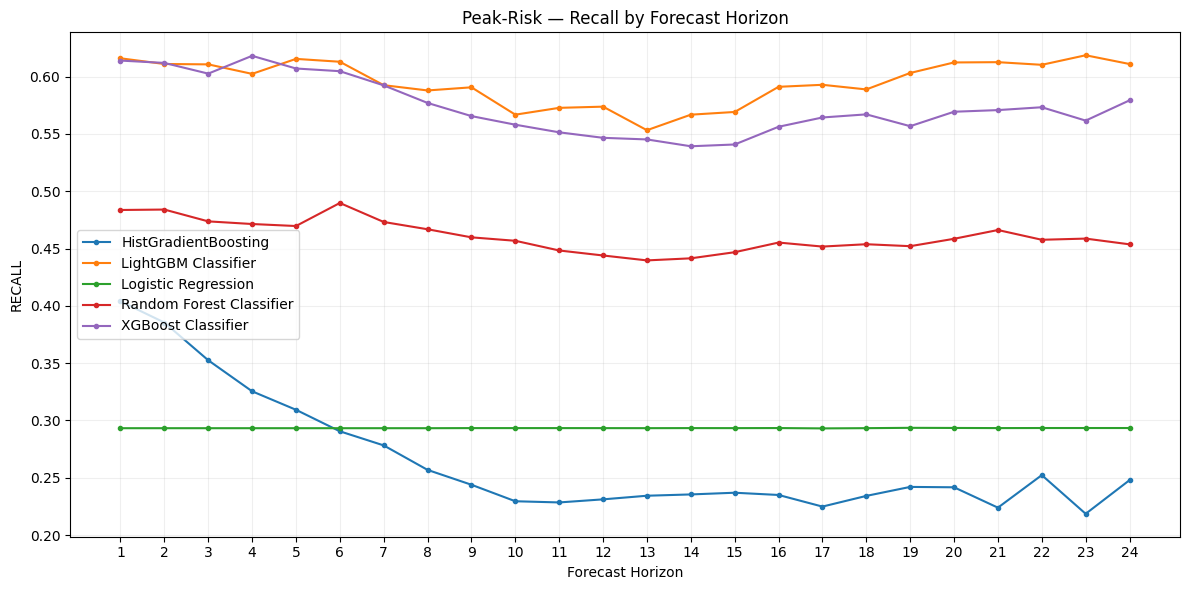

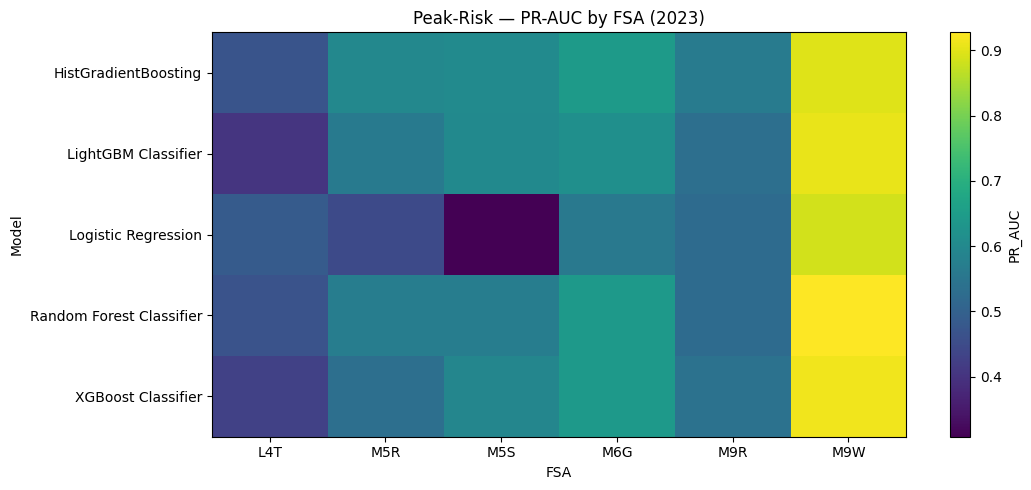

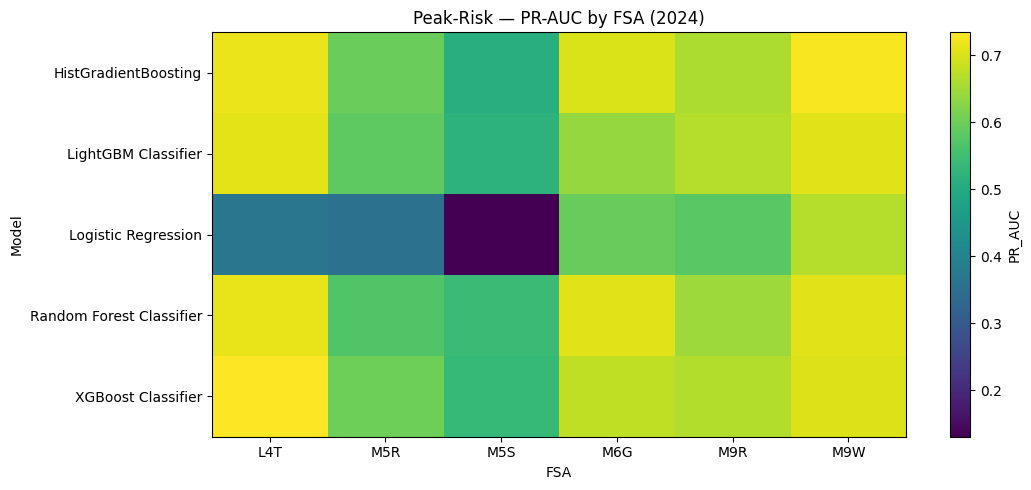

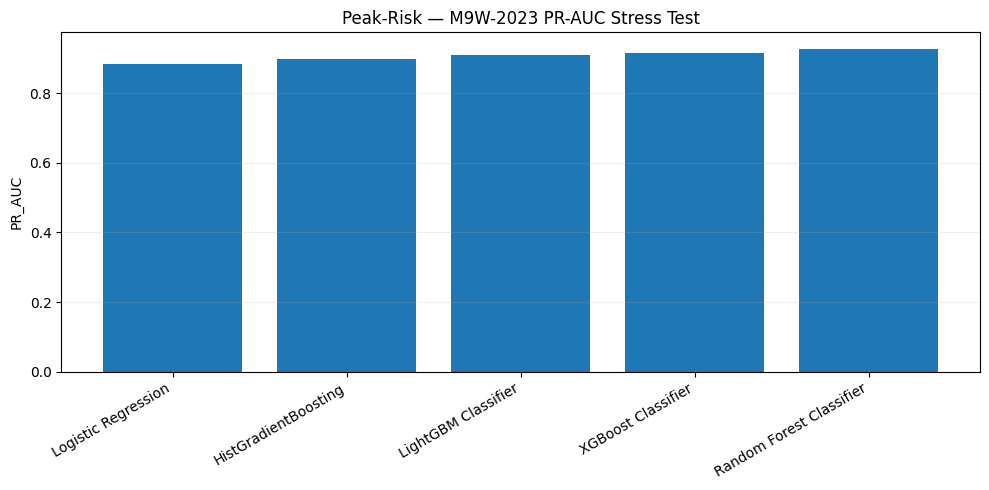

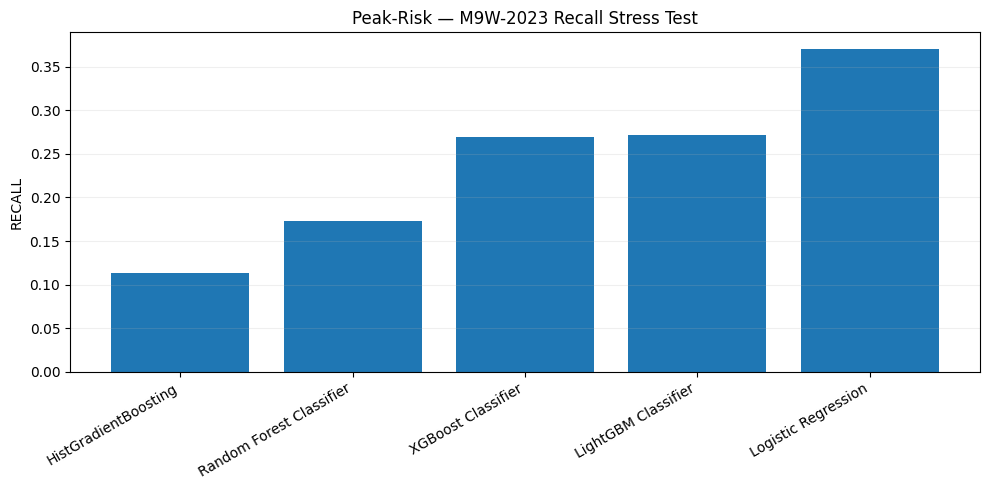

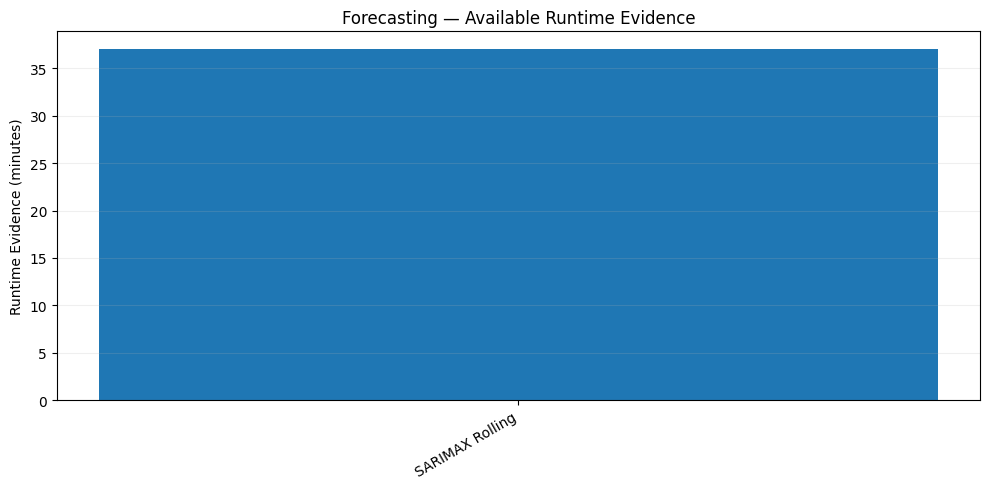

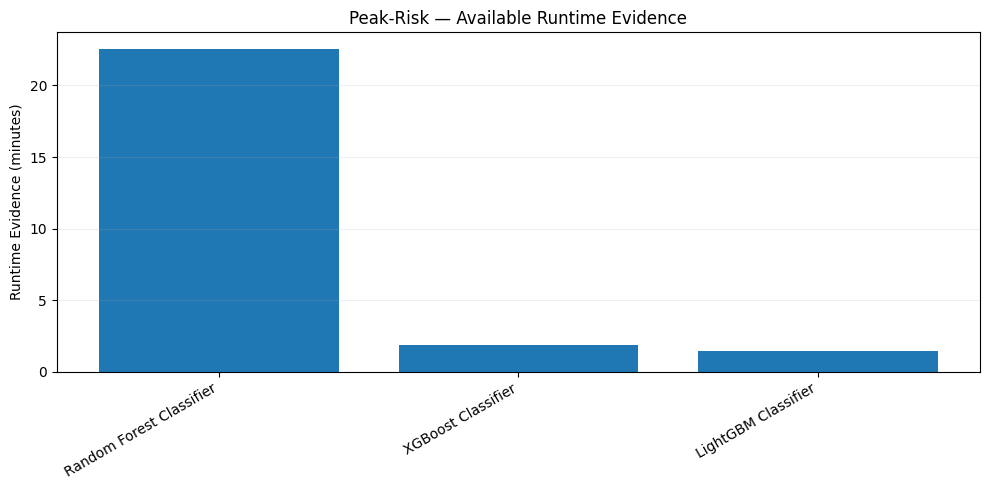

In [2]:
from src.ontario_peak_risk.model_comparison.run_comparison import run_model_comparison

results = run_model_comparison(CONFIG_PATH)

display(results["forecasting_selection"])
display(results["peak_selection"])
results["recommendation"]


## Decision rule

The top row is the **primary-metric candidate**, not an automatic final winner.

Before approving the candidate, inspect:

- fold stability;
- FSA stability;
- horizon behavior;
- M9W-2023;
- calibration for Peak-Risk;
- runtime evidence where available.

If the primary candidate shows a material guardrail failure, document the trade-off rather than silently replacing the declared primary metric.